In [1]:
!pip install torchinfo

# **Import Libraries**

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
from PIL import Image
from tqdm.notebook import tqdm
import psutil
import platform

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from itertools import cycle

# **System Information**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# **Configuration**

In [4]:
data_dir = "/kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer"
output_dir = "/kaggle/working/processed-dataset"  
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoints_path, exist_ok=True)

train_batch = 32
test_batch = 16
total_class = 5 
learning_rate = 0.0001
decay = 1e-4
epoch = 100   
patience = 10


# **Data Loader**

In [5]:
def load_data(root_dir):
    file_paths = []
    labels = []
    print(f"Scanning directory: {root_dir}...")
    
    if not os.path.exists(root_dir):
        print(f"ERROR: Directory not found: {root_dir}")
        return pd.DataFrame()

    classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    print(f"Detected classes: {classes}")

    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        for root, dirs, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                    file_paths.append(os.path.join(root, file))
                    labels.append(class_name)

    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    
    if not df.empty:
        df['filename_stem'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
        df = df.drop_duplicates(subset=['label', 'filename_stem']).drop(columns=['filename_stem'])

    print(f"Total images found: {len(df)}")
    return df

data = load_data(data_dir)

Scanning directory: /kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer...
Detected classes: ['cervix_koc', 'cervix_dyk', 'cervix_pab', 'cervix_sfi', 'cervix_mep']
Total images found: 25000


# **Data Split and Preprocessing**

In [6]:
train_dataframe, temp_dataframe = train_test_split(data, test_size=0.30, stratify=data['label'], random_state=42)
validation_dataframe, test_dataframe = train_test_split(temp_dataframe, test_size=0.50, stratify=temp_dataframe['label'], random_state=42)

def data_preprocess(df, split_name, size=(224, 224), quality=100):
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    processed_file_paths = []

    print(f"Processing {split_name} images...")
    for idx, row in df.iterrows():
        label = row['label']
        label_dir = os.path.join(split_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        try:
            img = Image.open(row['file_path']).convert("RGB")  
            img = img.resize(size, Image.Resampling.LANCZOS)
            file_name = f"{idx}.jpg"
            save_path = os.path.join(label_dir, file_name)
            img.save(save_path, optimize=True, quality=quality)
            processed_file_paths.append(save_path)
        except Exception:
            processed_file_paths.append(row['file_path'])

    df['file_path'] = processed_file_paths
    return df

train_dataframe = data_preprocess(train_dataframe, "train")
validation_dataframe = data_preprocess(validation_dataframe, "val")
test_dataframe = data_preprocess(test_dataframe, "test")

Processing train images...
Processing val images...
Processing test images...


# **Dataset and Transforms** 

In [7]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = PIL.Image.open(row['file_path']).convert("RGB")
        label = self.label_map[row['label']]
        if self.transform:
            image = self.transform(image)
        return image, label


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(train_dataframe, transform=train_transform)
valid_dataset = ImageDataset(validation_dataframe, transform=val_test_transform)
test_dataset = ImageDataset(test_dataframe, transform=val_test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2)
validation_dataloader = DataLoader(valid_dataset, batch_size=test_batch, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2)

print("DataLoaders ready.")

DataLoaders ready.


# **Attention Modules (CBAM)**

In [9]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

# **Attention-Enhanced CNN Model**

In [10]:
class CervicalCancerNet_Attention(nn.Module):
    def __init__(self, num_classes):
        super(CervicalCancerNet_Attention, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.cbam1 = CBAM(32) 
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.cbam2 = CBAM(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.cbam3 = CBAM(128)

        # Block 4
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.cbam4 = CBAM(256)

        # Pooling
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        # --- Classifier ---
        self.flatten = nn.Flatten()
        # Input calculation: 224 -> 112 -> 56 -> 28 -> 14. 256 channels * 14 * 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.cbam1(x) # Apply Attention
        
        # Block 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.cbam2(x) # Apply Attention
        
        # Block 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.cbam3(x) # Apply Attention
        
        # Block 4
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.cbam4(x) # Apply Attention
        
        # Classifier
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
model = CervicalCancerNet_Attention(total_class).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=decay)

print("Attention-Enhanced Model Initialized.")

Attention-Enhanced Model Initialized.


# **Training Loop**

In [12]:
def train_attention_model(model, train_loader, val_loader, num_epochs, patience):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    start_time = time.time() 
    print("Starting Training...")
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / total
        epoch_acc = correct / total
    
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / val_total
        val_epoch_acc = val_correct / val_total
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        
        print(f"Epoch {epoch+1}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")
        
        # Early Stopping & Checkpointing
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), f"{checkpoints_path}/attention_model_best.pt")
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break
            
    training_time = time.time() - start_time
    print(f"\nTotal Training Duration: {training_time:.2f} seconds")
    return history, training_time

In [13]:
history, train_duration = train_attention_model(model, train_dataloader, validation_dataloader, epoch, patience)

Starting Training...


Epoch 1/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 1: Train Loss: 0.5464 Acc: 0.7915 | Val Loss: 0.1932 Acc: 0.9333


Epoch 2/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2: Train Loss: 0.2554 Acc: 0.9106 | Val Loss: 0.1340 Acc: 0.9549


...

Epoch 73: Train Loss: 0.0071 Acc: 0.9982 | Val Loss: 0.0000 Acc: 1.0000


Epoch 74/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 74: Train Loss: 0.0039 Acc: 0.9987 | Val Loss: 0.0002 Acc: 1.0000


Epoch 75/100:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 75: Train Loss: 0.0070 Acc: 0.9978 | Val Loss: 0.0003 Acc: 0.9997
Early stopping triggered.

Total Training Duration: 5237.53 seconds


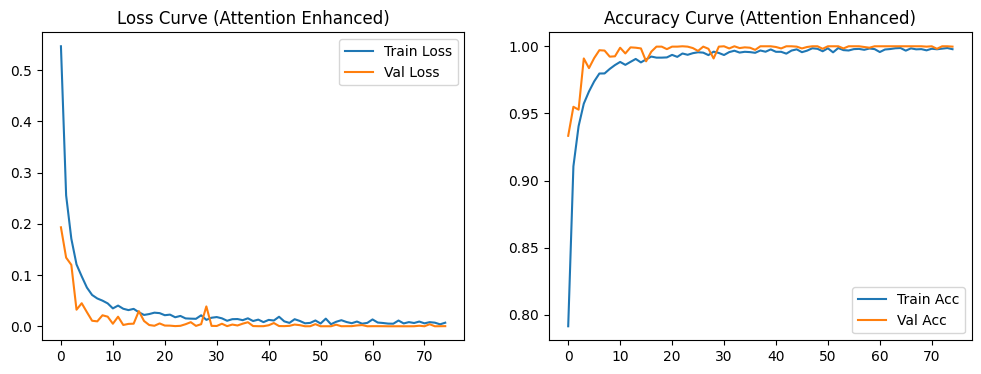

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Attention Enhanced)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve (Attention Enhanced)')
plt.legend()
plt.show()

# **Evaluation**


Loading Best Model for Evaluation...


Evaluating:   0%|          | 0/235 [00:00<?, ?it/s]

Testing Duration: 5.81 seconds

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  cervix_dyk       1.00      1.00      1.00       750
  cervix_koc       1.00      1.00      1.00       750
  cervix_mep       1.00      1.00      1.00       750
  cervix_pab       1.00      1.00      1.00       750
  cervix_sfi       1.00      1.00      1.00       750

    accuracy                           1.00      3750
   macro avg       1.00      1.00      1.00      3750
weighted avg       1.00      1.00      1.00      3750



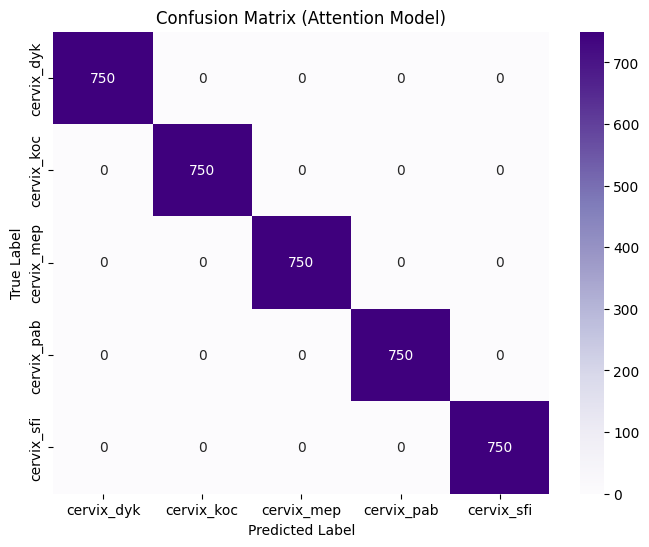


--- Class-wise Accuracy ---
cervix_dyk: 100.00%
cervix_koc: 100.00%
cervix_mep: 100.00%
cervix_pab: 100.00%
cervix_sfi: 100.00%

--- ROC Curves & AUC ---


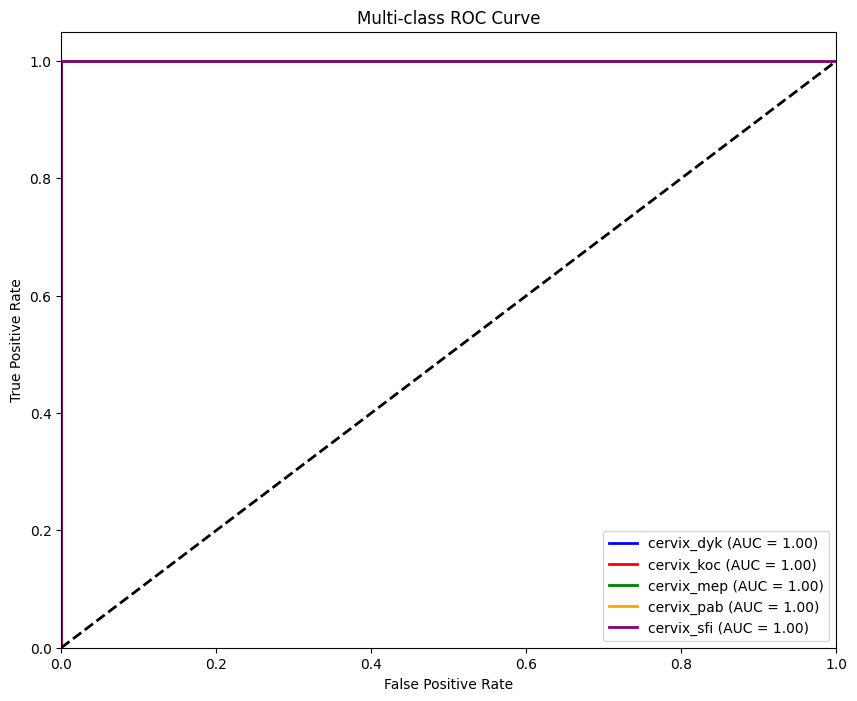

In [15]:
def evaluate_attention(loader, class_map):
    print("\nLoading Best Model for Evaluation...")
    model.load_state_dict(torch.load(f"{checkpoints_path}/attention_model_best.pt", map_location=device))
    model.eval()
    
    y_true = []
    y_pred = []
    y_probs = []
    
    start_test = time.time()
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Get probabilities for ROC
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            
    test_duration = time.time() - start_test
    print(f"Testing Duration: {test_duration:.2f} seconds")
    
    # Map indices back to class names
    idx_to_class = {v: k for k, v in class_map.items()}
    target_names = [idx_to_class[i] for i in range(len(class_map))]
    
    # 1. Classification Report (Precision, Recall, F1)
    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Attention Model)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # 3. Class Accuracy
    print("\n--- Class-wise Accuracy ---")
    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    for i, acc in enumerate(class_acc):
        print(f"{target_names[i]}: {acc*100:.2f}%")
        
    # 4. AUC and ROC Curve
    print("\n--- ROC Curves & AUC ---")
    y_true_bin = label_binarize(y_true, classes=range(len(target_names)))
    y_probs = np.array(y_probs)
    
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    
    for i, color in zip(range(len(target_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{target_names[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Run Evaluation
evaluate_attention(test_dataloader, train_dataset.label_map)

# LIBRARY INSTALLATION

In [22]:
%%capture
!pip install grad-cam

In [23]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

 # Image Denormalization Helper

In [18]:
# 1. Define Helper to Denormalize Images (for visualization)
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

# Grad-CAM Configuration & Target Layer

In [21]:
# 2. Setup Grad-CAM
# We target 'model.conv4' which is defined in  'CervicalCancerNet_Attention' class
target_layers = [model.conv4] 
cam = GradCAM(model=model, target_layers=target_layers)

# Visualization Logic

In [1]:
# 3. Visualization Function
def visualize_gradcam(loader, num_images=5):
    print("Generating Grad-CAM for Task 4 Model...")
    model.eval()
    
    # Get a batch from the EXISTING test_dataloader
    images, labels = next(iter(loader))
    images = images.to(device)
    
    # Get predictions
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    
    # Map indices to class names (Using the map created in Task 2/3)
    idx_to_class = {v: k for k, v in train_dataset.label_map.items()}
    
    plt.figure(figsize=(20, 8))
    
    for i in range(min(len(images), num_images)):
        input_tensor = images[i].unsqueeze(0)
        
        # We target the class the model PREDICTED
        targets = [ClassifierOutputTarget(preds[i].item())]
        
        # Generate the heatmap
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        
        # Overlay on original image
        rgb_img = denormalize(images[i])
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        
        # Plot
        plt.subplot(1, num_images, i + 1)
        plt.imshow(visualization)
        
        true_label = idx_to_class[labels[i].item()]
        pred_label = idx_to_class[preds[i].item()]
        
        col = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=col, fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()